In [188]:
%matplotlib inline
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np
from jax import random
import seaborn as snb

import bayesian

# use 64-bit precision
from jax import config
config.update("jax_enable_x64", True)

# style stuff
snb.set_style('darkgrid')
snb.set_theme(font_scale=1.25)
colors = snb.color_palette()

# 02477 Bayesian Machine Learning Exam Template

A lot of justification and notes are written in the code comments. Most of the analytical results and justifications can be found in the handwritten appendix.

Student number: s214615

# Part 1
Questions Q1.1 through Q1.5: See handwritten solution on appendix A

In [189]:
# Part 1
sigma = 1/10
alpha = 1
x = jnp.array([-0.3, 1.3, -0.7, 1.2, -0.2])
y = jnp.array([2.1, -1, 0.7, -0.7, 1.7])
# Q 1.1 See handwriten answer.

# Q 1.2
# We recognize that is a linear regression model with a feature transformation.
# We first contstruct the feature matrix X
X = jnp.array([jnp.cos(2*jnp.pi*x*(k/3)) for k in range(4)]).T
# Now it is simply a linear regression problem of the form y = X @ Theta with added noise

# We determine the MAP estimator on closed form using the results form lecture 3 on bayesian linear regression
beta = 1/(sigma**2) # Reparameterize as precision
S = jnp.linalg.inv(alpha * jnp.eye(4) + beta * X.T @ X)
m = beta * S @ X.T @ y
# theta_map = jnp.linalg.solve(X.T @ X, X.T @ y)
print(f'The map estimate of theta is: m = {m}\n')

# Q1.3
# The prior distribution of theta1 is just a gaussian.
import scipy
print(f'95% interval for p(w1) = {(scipy.stats.norm.interval(0.95, loc = 0, scale = jnp.sqrt(alpha**-1) ))} \n')

#print(scipy.stats.norm.cdf(1.959963984540054, scale=jnp.sqrt(alpha**-1)))
#print(scipy.stats.norm.cdf(1.959963984540054/jnp.sqrt(alpha**-1))) # It checks out

# Since we have the exact posterior distriution of theta, it is now simple to
# marginalize over theta 1 and compute a confidence interval since the
# posterior distribution of theta 1 is a gausian

print(f'95% interval for p(w1|y) = {(scipy.stats.norm.interval(0.95, loc = m[1], scale = jnp.sqrt(S[1,1])))} \n')


# Q1.4
x_star = 3 
X_star = jnp.array([jnp.cos(2*jnp.pi*x_star*(k/3)) for k in range(4)]).T
print(f"{X_star=}, Note that in this case X_star exactly matches the period of the feature transformation\n") 
# In this case X_star exactly matches the period of the feature transformation

# See Appendix A for derivation
mu_ystar = X_star @ m
Sigma_ystar  = sigma**2 + X_star @ S @ X_star
print(f'The posterior predictive distribution p(y*|y, x* = 3): mu = {mu_ystar:3.5f}, Sigma = {Sigma_ystar}\n')


# Q 1.5
# See appendix A for derivation. We apply the marginalization result for linear gaussian systems.
mu_y = jnp.zeros(len(y))
Sigma_y = sigma**2 * jnp.eye(len(y)) + alpha**-1 * X @ X.T

from bayesian import mvn_logpdf # scipy wrapper
from jax.scipy.stats import multivariate_normal as mvn
logpy = mvn.logpdf(y, mu_y,  Sigma_y)
print(f'log p(y) for the given dataset is: {logpy}')

# value = 1.23456789
# print(f'expected value for hat y = 0: {value:3.5f}')

The map estimate of theta is: m = [ 0.51255588  1.58660269 -0.01927582 -0.27540388]

95% interval for p(w1) = (np.float64(-1.959963984540054), np.float64(1.959963984540054)) 

95% interval for p(w1|y) = (np.float64(1.47304509905509), np.float64(1.700160283996065)) 

X_star=Array([1., 1., 1., 1.], dtype=float64), Note that in this case X_star exactly matches the period of the feature transformation

The posterior predictive distribution p(y*|y, x* = 3): mu = 1.80448, Sigma = 0.03871907613156604

log p(y) for the given dataset is: -11.359552536151698


# Part 2
Solution to Q2.1 through Q2.5: See handwritten solution on appendix B


## Q2.1
Since we are dealing with positive count data without a natural
upper bound, a natural distribution for the likelyhood would be the
poisson distribution. 
Since the poission distribution is parameterized by a positive
parameter lambda, a natural link function would be the exponential function
If we instead prefer more linear like scaling of the lambda parameter for positive values, we can chose the softplus link function instead.
Both functions are defined later in the code and can be found in the reference material of the course.

# Q2.2
We have an isotropic gaussian as the prior. See Appendix B for the derivation.
We use the fact the gaussian is symmetric at 0 to only consider w < 3 part.

1.959963984540054
alpha has the value 0.42682875785490276
95% interval for p(w1) = (np.float64(-3.0), np.float64(3.0))
prob of |w1| < 3 evaluated through sampling for the found value of alpha: 0.95032


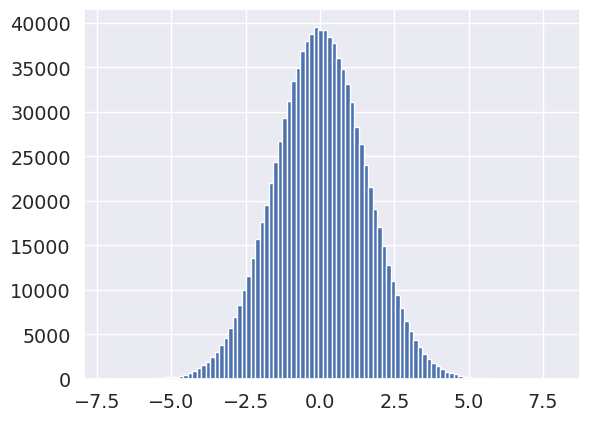

In [190]:


x = scipy.stats.norm.ppf(0.975)
print(x)
alpha = (x/3)**2
print(f'alpha has the value {alpha}')
print(f'95% interval for p(w1) = {(scipy.stats.norm.interval(0.95, loc = 0, scale = jnp.sqrt(alpha**-1)))}')

# print(f'95% interval for p(w1) = {(scipy.stats.norm.interval(0.95, loc = 0, scale = jnp.sqrt(0.4**-1)))}')

N = 1000000
seed = 0
key = random.key(seed)
# lpha = 1.50 # About 1.50
samples = random.normal(key, (N,)) / jnp.sqrt(alpha)
print(f"prob of |w1| < 3 evaluated through sampling for the found value of alpha: {(jnp.abs(samples) < 3).mean():3.5f}")
plt.hist(samples, bins=100)
plt.show()


# Part 3
Questions Q3.1 through Q3.5: See handwritten solution on appendix C

The acceptance probabily for x* given x0 is  0.43848
MCMC done: accept_rate=0.547  t=0.2s


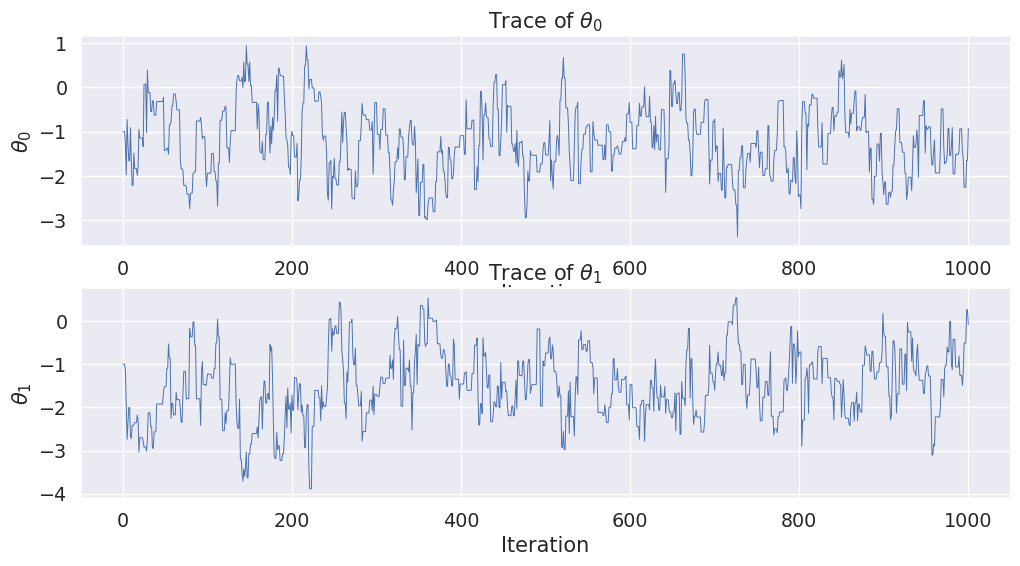

In [191]:
# Part 3
def sigmoid(x):
    return 1.0 / (1.0 + jnp.exp(-x))

def softplus(x):
    return jnp.log(1.0 + jnp.exp(x))

# Unnormalized distribution
log_target = lambda x : -1/2 * (x.T @ x) -20*softplus(x.sum())
# Note the last one vector is just there to make the dimensionality check out in the math
log_grad = lambda x : -x -20*sigmoid(x.T @ jnp.ones(x.shape)) # * jnp.ones(len(x))
log_grad2 = lambda x : -x -20*sigmoid(x.T.sum(-1)) # Should be identical

x0 = jnp.array([-1, -1])
x_star = jnp.array([-2, -2])

# Q3.1
p_x0 = log_target(x0)
p_xstar = log_target(x_star)
accept_prob = jnp.exp(p_xstar - p_x0)
print(f'The acceptance probabily for x* given x0 is  {accept_prob:3.5f}')
# This value seems reasonable give the trace plot and the distribution

# Q3.2
num_iterations = 1000
tau = jnp.sqrt(1/2)
from bayesian import metropolis, plot_trace, plot_mcmc_diagnostics
seed = 0
key = random.key(seed)
key, metropolis_key = random.split(key, 2)

thetas = metropolis(log_target, 2, tau, num_iterations, x0)
fig, ax = plt.subplots(2,1, figsize = (12, 6))
plot_trace(ax, thetas)
#plot_mcmc_diagnostics(thetas)


In [192]:
# Q3.3
# We estimate expectation of the function g(x1, x2) = x1*x2**2
# using the MCMC samples from p(x) from earlier
print(thetas.shape) 
# Note that we include the intial sample x0.
# This sample could arguably be discarded, but judging from the 
# trace plots, it does not seem out of distribution, and it is of  limited significance with 1000 new samples
g = thetas[:, 0] * (thetas[:,1]**2) # point wise multiplication
g.shape
print(g.mean())
print(f'The expectation of the function g(x1, x2) = x1*x2**2 as approximated using the MCMC samples is: {g.mean():3.5f}')

(1001, 2)
-2.3781956622456604
The expectation of the function g(x1, x2) = x1*x2**2 as approximated using the MCMC samples is: -2.37820


In [193]:
# Q3.4
nu0 = jnp.array([0, 2])
eta = 1/2
# log_grad(x0) = 1-20*sigmoid(-2)

# Apply a single step of the leapfrog integrator
nu_12 = nu0 - eta/2 * log_grad(x0)
x1 = x0 + eta * nu_12
nu1 = nu_12 - eta/2 * log_grad(x1)

print(f'The proposed state (x*, nu*) after a single leapfrog step is\n x* = {x1}, nu* = {nu1}')

# Verified using a different method

def leapfrog(theta,
             nu,
             grad_potential,
             num_steps: int,
             step_size: float):
    """Leapfrog integrator for Hamiltonian dynamics.

    arguments:
        theta:          current position, shape (D,)
        nu:             current momentum, shape (D,)
        grad_potential: callable ∇U(theta), shape (D,) → (D,)
        num_steps:      number of leapfrog steps L
        step_size:      step size ε

    returns:
        theta:  updated position, shape (D,)
        nu:     updated momentum, shape (D,)
    """
    for _ in range(num_steps):
        nu    = nu    - 0.5 * step_size * grad_potential(theta)
        theta = theta + step_size * nu
        nu    = nu    - 0.5 * step_size * grad_potential(theta)
    return theta, nu

print(f'Calculated again using a different function: {leapfrog(x0, nu0, log_grad, 1, eta)}\n')

# Q3.5
x_star = jnp.array([-1, -3])
nu_star = jnp.array([-1, -1/2])
# As stated in the problem, we assume nu follows a standard 2 dimensional normal distribution
log_npdf = lambda x, m, v: -(x-m)**2/(2*v) - 0.5*jnp.log(2*jnp.pi*v) # v is the variance

def potential(theta) :
    return -log_target(theta)

def kinetic_energy(nu) :
    return -log_npdf(nu, 0, 1).sum()

def hamiltonian(theta, nu):
    return potential(theta) + kinetic_energy(nu) # 0.5 * jnp.dot(nu, nu) # This distinction actually doesn't matter because we only care about relative densities

log_accept = jnp.minimum(0.0, -hamiltonian(x_star, nu_star) + hamiltonian(x0, nu0))

print(f'The probability of accepting the state (x*, nu*) given the current state is: {jnp.exp(log_accept)}')


#from bayesian import HMC
# HMC(log_target, 10, x0, )

The proposed state (x*, nu*) after a single leapfrog step is
 x* = [-0.82699269  0.17300731], nu* = [1.84972644 4.09972644]
Calculated again using a different function: (Array([-0.82699269,  0.17300731], dtype=float64), Array([1.84972644, 4.09972644], dtype=float64))

The probability of accepting the state (x*, nu*) given the current state is: 0.6379863840390008


# Part 4
Questions Q4.1 through Q4.5: See handwritten solution on appendix D

# Q4.1
Since the prior distribution is an isotropic gaussian distribution
with 0 mean, of the two the MAP estimate must be W_A and the
ML (maximum likelyhood) estimate must be W_B, because the prior
weighs the MAP estimate in the direction of the mean of the prior.

For an isotropic gaussian prior with mean 0 like this one, 
it would be impossible for the MAP estimate to lie further away from the mean of the prior
than the ML estimate, since the prior density is monotonically increasing towards the
mean from all directions. Therefore it downweighs the probability of the ML estimate compared to
everything closer to the prior mean in the L2 norm sense.

p(y*|y, x*): Ber(0.76852)

Q4.3 Sampling from the variational approximation 
p(y*|y, x*): Ber(0.72260)


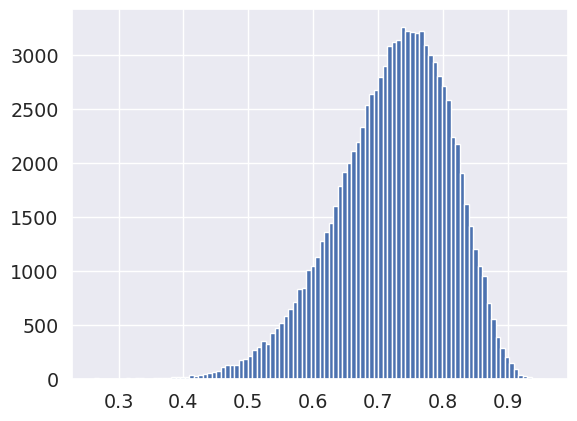

In [194]:
# Part 4

# Q4.2  # See appendix D for handrwitten justification
w_a = jnp.array([2.09, -0.89]) #MAP
w_b = jnp.array([2.42, -1.01]) #ML

x_star = jnp.array([1,  1]) # add 1 for the intercept term
p_x_star = sigmoid(w_a @ x_star)
print(f'p(y*|y, x*): Ber({p_x_star:3.5f})\n') 

# Q4.3 # See appendix D for handrwitten justification
tau2 = 1/10
# The variational family consists of mean-field gaussians with
# identical variance in all dimensions
# A gaussian ball/circle if you will.
m = jnp.array([2, -1])

# Sample from the approximate posterior and compute and plot the 
# approximate predictive distribution
seed = 0
key = random.key(seed)
key, mvn_key = random.split(key, 2)
num_samples = 100000
ws = random.multivariate_normal(mvn_key, m, tau2 * jnp.eye(2), shape=(num_samples,))

ps_x_star = sigmoid(ws @ x_star)
print(f'Q4.3 Sampling from the variational approximation \np(y*|y, x*): Ber({ps_x_star.mean():3.5f})') 
plt.hist(ps_x_star, bins=100) 
# As we see in the histogram
# The estimator has quite some variance unless we take many samples
plt.show()




## Q4.4
The entropy of a multivariate gaussian does not depend on its mean. The entropy of a multivariate gaussian only depends on the covariance matrix (and arguably the dimension if this cannot be infered for the encoding of the covariance matrix) and thus it is constant no matter the optimal variational approximation q* for this variational family. 
In this particular case it is even simpler since it is a mean field gaussian with constant variance in all dimensions.

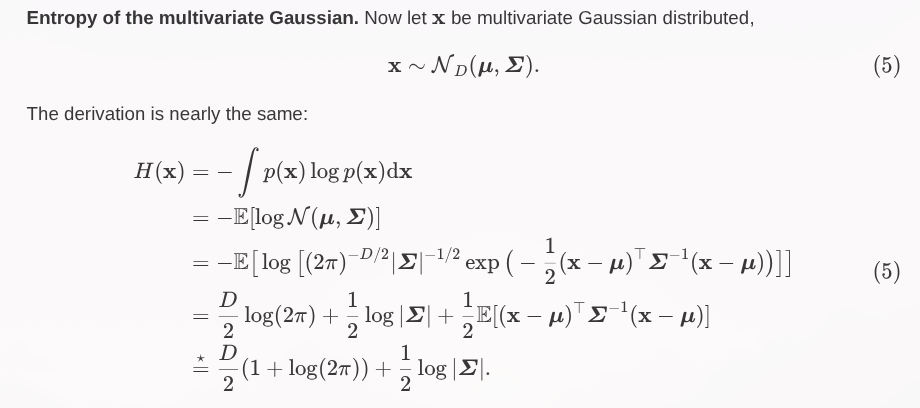




In [195]:
def compute_entropy(v):
    """Entropy of mean-field Gaussian: sum_d 0.5*(log(2*pi*v_d) + 1).""" # Same formula as above in a different format
    return 0.5 * jnp.sum(jnp.log(2 * jnp.pi * v) + 1.0)

entropy = compute_entropy(tau2*jnp.ones(2))
print(f'The entropy all members of this variational family including the optimal approximation is\n H(q) = {entropy}') 


The entropy all members of this variational family including the optimal approximation is
 H(q) = 0.5352919734152998


# Part 5
Questions Q5.1 through Q5.5: See handwritten solution on appendix E

In [196]:
# Part 5
sigma2 = 1/3
from bayesian import Hyperparameters, StationaryIsotropicKernel, GaussianProcessRegression, plot_data
# Assuming that the norm is the l2 norm, this is a squared exponential kernel
kappa = 2
lengthscale = jnp.sqrt(0.5)

def squared_exponential(tau, hyperparameters: Hyperparameters): # Beware, tau is the norm, not the squared norm
    return hyperparameters.kappa**2*jnp.exp(-0.5*tau**2/hyperparameters.lengthscale**2)

X = jnp.array([0, 0, 0, 1, 1, 0, 1, 1]).reshape(4,2)
y = jnp.array([-0.25, 0.42, 0.49, -1.17])[:, None]
x_star = jnp.array([1/2, 1/2])[None, :]

# Q5.1 # See handwritten notes for calculation as well
hyper = Hyperparameters(kappa, lengthscale, jnp.sqrt(sigma2))

print(squared_exponential(jnp.sqrt(x_star@x_star.T), hyper))
print(4*jnp.exp(-1/2))
Sigma_star_prior = 4*jnp.exp(-1/2) + sigma2

print(f'The prior predictive distribution p(y*|x*): mu = {0:3.5f}, Sigma = {Sigma_star_prior}')


[[2.42612264]]
2.4261226388505337
The prior predictive distribution p(y*|x*): mu = 0.00000, Sigma = 2.759455972183867


In [ ]:
# Q5.2
# Good old gaussian process regression
# We apply the formulas and results from Murphy and lecture 5
kernel = StationaryIsotropicKernel(squared_exponential)
K = kernel.construct_kernel(X, X, hyper)
Ks = kernel.construct_kernel(X, x_star, hyper)
Kss = kernel.construct_kernel(x_star, x_star, hyper)

C = K + sigma2 * jnp.eye(len(K))
mu_x_star = Ks.T @ jnp.linalg.solve(C, y)
Sigma_x_star = Kss - Ks.T @ jnp.linalg.solve(C, Ks) + sigma2 * jnp.eye(len(K))
print(f'The predictive distribution p(y*|y, x*): \nmu = {mu_x_star}, \nSigma = {Sigma_x_star}')
# It makes sense since x4 has a negative target value y4. 
model = GaussianProcessRegression(X, y, kernel, hyper)
# from bayesian import plot_with_uncertainty
# plot_with_uncertainty(kernel, hyper, X, y, x_star)



The predictive distribution p(y*|y, x*): 
mu = [[-0.15827174]], 
Sigma = [[1.32167338 0.98834005 0.98834005 0.98834005]
 [0.98834005 1.32167338 0.98834005 0.98834005]
 [0.98834005 0.98834005 1.32167338 0.98834005]
 [0.98834005 0.98834005 0.98834005 1.32167338]]


## Q5.3

Here f is sampled from the prior distribution given the input points x.
The distribution of f* can be determined by constructing the full kernel for [x, x*] (all data points)
and then conditioning on x*. We can use the equations for linear gaussian systems in Murphy 1.
See the handwritten notes in Appendix E and the analytical solution. The answer is conditioned on f, for which we do not have data or samples given.



## Q5.4
See appendix E handwritten notes